In [1]:
from PySide2.QtCore import QTimer, QTime, Signal
import time
import numpy as np
import os
import sys

# Get the absolute path of the current script
script_path = os.path.abspath(r"C:\Users\YY3\GIT\squdi\src\qudi\jupyternotebooks\hom")
# Get the directory name of the script path
script_dir = os.path.dirname(script_path)
# Change the working directory to the script's directory
os.chdir(script_dir)
from hom import auto2
from hom.auto2 import *
from hom.tools import *
%gui qt

In [55]:
folder_save = r'Z:\Vlad\SnV\TPI\Electrodes_e4\178-e4-stats\def3\dump'
current_cryo = 'atto3' #fix the notation of current and non-active cryo
non_active_cryo = 'bf'
integrate_for_mins = 180
values = [0, -.2, -.5, -0.8, -1.13]  #the counts have to be equalized!

params = {
    'ple_gui': ple_gui,
    'laser_scanner_logic': laser_scanner_logic,
    'scanner_gui' : scanner_gui,
    'scanning_data_logic' : scanning_data_logic,
    'pulsestreamer' : pulsestreamer,
    'timetaggerlogic': timetaggerlogic,
    'timetagger': timetagger,
    'timetagger_remote': timetagger_remote,
    'timetaggerlogic_remote': timetaggerlogic_remote,
    'poi_manager_logic_remote': poi_manager_logic_remote,
    'poi_manager_logic': poi_manager_logic,
    'switchlogic': switchlogic,
    'ibeam_smart_remote': ibeam_smart_remote,
    'powercontroller_logic': powercontroller_logic,
    'integrate_for_mins': integrate_for_mins,
    'current_cryo': current_cryo,
    'non_active_cryo': non_active_cryo,
    'folder_save': folder_save,
    'values': values,
}

measurement_e_hom = auto2.StarkHOM(ao_electrodes_remote, **params)  
measurement_e_hom.ao_electrodes._current_channel='ao3'
measurement_e_hom.ao_electrodes._constraints._channel_limits = {'ao3': [-1.38, 1.38]}
measurement_e_hom.min_position = 80
measurement_e_hom.max_position = 180
measurement_e_hom.max_power = 30e3
measurement_e_hom.perpendicular_position = 0
measurement_e_hom.parallel_position = 22
measurement_e_hom.polarization_is_parallel = False

measurement_e_hom.measurement_setpoints = [0, -0.2, -0.4, -0.6]
measurement_e_hom.to_refocus_ple = False

In [125]:
measurement_e_hom.measurement_mode('Off-res')

In [124]:
#Find overlapping defects
measurement_e_hom.measurement_mode('PLE')

In [4]:
measurement_e_hom.calibrate_counts('bf', 'atto3', steps = 100)

In [7]:
from matplotlib import pyplot as plt

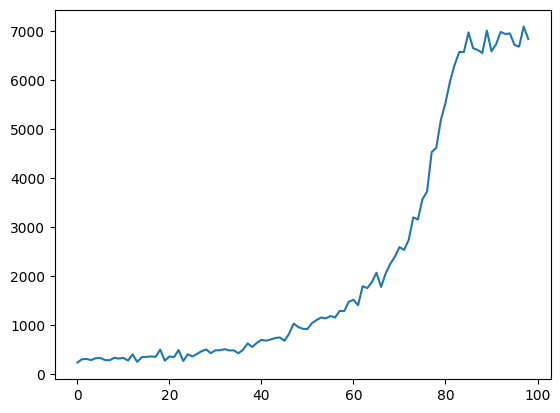

In [8]:
plt.plot(measurement_e_hom.counts_calibration['bf'])

In [13]:
measurement_e_hom.min_position = 80
measurement_e_hom.max_position = 180

In [44]:
measurement_e_hom.max_power = 30e3

In [121]:
measurement_e_hom.set_green_power('bf', 30e3)

In [119]:
measurement_e_hom.set_green_power('atto3', 30e3)

In [86]:
measurement_e_hom.perpendicular_position = -1

In [42]:
measurement_e_hom.parallel_position = 22

In [95]:
measurement_e_hom.polarization_is_parallel = True

In [92]:
measurement_e_hom.refocus(optimize_both=True)

In [9]:
measurement_e_hom.get_counts(channels=[3]).sum()

9176.0

In [16]:
measurement_e_hom.align_resonances(dv=0.3, steps=30)

(array([50484., 45477., 45447., 44780., 45505., 45366., 45324., 46507.,
       46912., 47847., 48535., 48433., 49920., 50883., 49843., 51868.,
       52145., 53437., 53826., 53190., 52487., 53602., 54822., 54980.,
       53160., 53968., 54292., 54713., 56112., 53987., 54557., 54982.,
       54885., 53974., 54775., 53401., 49585., 42045., 33111., 32525.,
       30888., 34479., 30502., 32185., 30209., 32210., 29458., 30388.,
       30529., 29572.]), array([-0.5975976 , -0.58127107, -0.56494454, -0.54861801, -0.53229148,
       -0.51596494, -0.49963841, -0.48331188, -0.46698535, -0.45065882,
       -0.43433229, -0.41800576, -0.40167923, -0.3853527 , -0.36902617,
       -0.35269964, -0.33637311, -0.32004658, -0.30372005, -0.28739352,
       -0.27106699, -0.25474045, -0.23841392, -0.22208739, -0.20576086,
       -0.18943433, -0.1731078 , -0.15678127, -0.14045474, -0.12412821,
       -0.10780168, -0.09147515, -0.07514862, -0.05882209, -0.04249556,
       -0.02616903, -0.0098425 ,  0.00648404

In [4]:
timetaggerlogic.trace_data_avg.keys()

dict_keys([1, 2, 3])

In [ ]:
measurement_e_hom.equalize_powers()

In [33]:
measurement_e_hom.measurement_mode('Off-res')

In [32]:
measurement_e_hom.polarization_is_parallel = False

In [131]:
def refocus():
    global iteration
    if iteration % 3 == 0:
        measurement_e_hom.refocus(optimize_both=True)
        
        time.sleep(1)
    
    measurement_e_hom.measurement_mode('PLE')
    time.sleep(1)
    measurement_e_hom.set_green_power('atto3', 6e3)
    measurement_e_hom.align_resonances(dv=0.3, steps=30)
    time.sleep(1)
    measurement_e_hom.measurement_mode('Off-res')
    
    iteration += 1
    
timer = QTimer()
timer.setInterval(240 * 1000)
timer.timeout.connect(refocus)
iteration = 0


In [101]:
measurement_e_hom.start_measurement()

In [126]:
measurement_e_hom.ao_electrodes.setpoint

-0.5794794794794795

In [5]:
measurement_e_hom.ao_electrodes.setpoint = -0.1


In [132]:
timer.start(240 * 1000)

In [130]:
timer.stop()